In [1]:
import requests
import zipfile
import os
from pathlib import Path
import pandas as pd
import xarray as xr
import numpy as np
import contextily as ctx
import matplotlib.pyplot as plt
import easysnowdata

data_dir = Path("data/NH_SWE")
data_dir.mkdir(parents=True, exist_ok=True)

# Zenodo record ID and files to download
zenodo_record = "7565252"
files_to_download = {
    "metadata": "NH_SWE_METADATA.csv",
    "matrix": "NH_SWE_dataset_matrix_files.zip",
}

# Download files from Zenodo
base_url = f"https://zenodo.org/records/{zenodo_record}/files"

matrix_zip = data_dir / "NH_SWE_dataset_matrix_files.zip"
matrix_dir = data_dir / "matrix_files"

In [2]:
for key, filename in files_to_download.items():
    filepath = data_dir / filename
    if not filepath.exists():
        print(f"Downloading {filename}...")
        response = requests.get(f"{base_url}/{filename}")
        response.raise_for_status()
        with open(filepath, 'wb') as f:
            f.write(response.content)
        print(f"Downloaded {filename}")
    else:
        print(f"{filename} already exists")

# Extract the matrix zip file
if not matrix_dir.exists():
    print("Extracting matrix files...")
    with zipfile.ZipFile(matrix_zip, 'r') as zip_ref:
        zip_ref.extractall(matrix_dir)
    print("Extraction complete")

NH_SWE_METADATA.csv already exists
NH_SWE_dataset_matrix_files.zip already exists


In [3]:
# Load metadata
metadata = pd.read_csv(data_dir / "NH_SWE_METADATA.csv")
print(f"Loaded metadata for {len(metadata)} stations")
metadata.head()

Loaded metadata for 11071 stations


,NHSWEID,SOURCE,ORIGID,CN,STANAME,LAT,LON,ELEV,START,END,VALIDYEARS,rhonull,rhomax,Tbarstar,VP_DJF,meanmaxHS,meanpeakSWE,meanmaxSCD
0,10001,ECA&D,1,SE,VAEXJOE,56.86667,14.80000,166.0,19490901,20190430,65,147,378,0.5002,0.4600,0.25,49,51
1,10002,ECA&D,2,SE,FALUN,60.61667,15.61667,160.0,19490901,20220831,73,128,363,0.2402,0.3700,0.42,90,96
2,10003,ECA&D,3,SE,STENSELE,65.06667,17.16639,325.0,19490901,20040430,54,103,348,-0.1006,0.2467,0.75,167,175
3,10004,ECA&D,4,SE,LINKOEPING,58.40000,15.53306,93.0,19490901,20220831,73,146,376,0.4608,0.4567,0.27,51,48
4,10005,ECA&D,5,SE,LINKOEPING-MALMSLAETT,58.40000,15.53306,93.0,19490901,20220831,73,146,376,0.4608,0.4567,0.26,54,45


In [4]:
metadata['SOURCE'].value_counts()

SOURCE
GHCNd                                                            6478
ECA&D                                                            3050
RIHMI-WDC                                                         543
Matiu2020                                                         535
FMI                                                               204
MeteoSwisss-MeteoSchweiz                                          124
MeteoSwisss-WSL-Institut für Schnee- und Lawinenforschung SLF     102
MeteoSwisss-Autonome Provinz Bozen - Südtirol                      35
Name: count, dtype: int64

In [5]:
import geopandas as gpd

metadata_gdf = gpd.GeoDataFrame(
    metadata,
    geometry=gpd.points_from_xy(metadata['LON'], metadata['LAT']),
    crs='EPSG:4326'
)

# metadata_gdf.explore(
#     column='ELEV',
#     cmap='terrain',
#     tooltip=['NHSWEID', 'STANAME', 'CN', 'ELEV', 'VALIDYEARS'],
#     marker_kwds={'radius': 4},
# )

In [6]:
# Load coordinate vectors (small files)
nhsweid_file = matrix_dir / "NH_SWE_matrix_NHSWEID_vector.csv"
date_file = matrix_dir / "NH_SWE_matrix_Date_vector.csv"
swe_file = matrix_dir / "NH_SWE_matrix_SWE_mm.csv"
#density_file = matrix_dir / "NH_SWE_matrix_snowdensity_kgm3.csv"

nhsweid_ids = pd.read_csv(nhsweid_file, header=None)[0].values  # (11071,)
dates = pd.to_datetime(pd.read_csv(date_file, header=None)[0].values)  # (26662,)

# Read matrix values only — no index/column parsing, float32 to halve memory
swe_values = pd.read_csv(swe_file, header=None, dtype=np.float32).values  # (26662, 11071)
#density_values = pd.read_csv(density_file, header=None, dtype=np.float32).values

# Build xarray Dataset
ds = xr.Dataset(
    {'swe': (['time', 'station'], swe_values)},
    coords={'time': dates, 'station': nhsweid_ids},
)

ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 26663, station: 11071)
Coordinates:
  * time     (time) datetime64[ns] 213kB 1949-09-01 1949-09-02 ... 2022-08-31
  * station  (station) int64 89kB 10001 10002 10003 10004 ... 60259 60260 60261
Data variables:
    swe      (time, station) float32 1GB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan 0.0

In [7]:
# Add station metadata as coordinates
station_metadata = metadata.set_index('NHSWEID')
for src, dst in [('LAT', 'latitude'), ('LON', 'longitude'), ('ELEV', 'elevation'), ('CN', 'country'), ('STANAME', 'station_name')]:
    ds.coords[dst] = ('station', station_metadata.loc[ds.station.values, src].values)

# Add attributes
ds.attrs['title'] = 'NH-SWE: Northern Hemisphere Snow Water Equivalent dataset'
ds.attrs['source'] = 'https://zenodo.org/records/7565252'
ds.attrs['reference'] = 'Fontrodona-Bach et al., 2023, ESSD, https://essd.copernicus.org/articles/15/2577/2023/'

ds.swe.attrs['units'] = 'mm'
ds.swe.attrs['long_name'] = 'Snow Water Equivalent'

ds

<xarray.Dataset> Size: 1GB
Dimensions:       (time: 26663, station: 11071)
Coordinates:
  * time          (time) datetime64[ns] 213kB 1949-09-01 ... 2022-08-31
  * station       (station) int64 89kB 10001 10002 10003 ... 60259 60260 60261
    latitude      (station) float64 89kB 56.87 60.62 65.07 ... 46.47 46.93 46.83
    longitude     (station) float64 89kB 14.8 15.62 17.17 ... 10.82 11.87 9.8
    elevation     (station) float64 89kB 166.0 160.0 ... 2.155e+03 2.691e+03
    country       (station) object 89kB 'SE' 'SE' 'SE' 'SE' ... 'IT' 'IT' 'CH'
    station_name  (station) object 89kB 'VAEXJOE' 'FALUN' ... 'Weissfluhjoch'
Data variables:
    swe           (time, station) float32 1GB 0.0 0.0 0.0 0.0 ... nan nan 0.0
Attributes:
    title:      NH-SWE: Northern Hemisphere Snow Water Equivalent dataset
    source:     https://zenodo.org/records/7565252
    reference:  Fontrodona-Bach et al., 2023, ESSD, https://essd.copernicus.o...

In [8]:
# see how large the dataset is in memory
print(f"Dataset size in memory: {ds.nbytes / 1e9:.2f} GB")

Dataset size in memory: 1.18 GB


In [9]:
# now spatially subset to Washington state
wa_ds = ds.where((ds.latitude >= 45) & (ds.latitude <= 49) & (ds.longitude >= -125) & (ds.longitude <= -116), drop=True)
wa_ds

<xarray.Dataset> Size: 25MB
Dimensions:       (time: 26663, station: 232)
Coordinates:
  * time          (time) datetime64[ns] 213kB 1949-09-01 ... 2022-08-31
  * station       (station) int64 2kB 50136 52231 52232 ... 56387 56388 56456
    latitude      (station) float64 2kB 49.0 48.4 48.41 ... 47.03 47.28 47.4
    longitude     (station) float64 2kB -118.8 -116.3 -116.4 ... -121.3 -120.2
    elevation     (station) float64 2kB 580.0 839.7 681.5 ... 1.207e+03 374.6
    country       (station) object 2kB 'CA' 'US' 'US' 'US' ... 'US' 'US' 'US'
    station_name  (station) object 2kB 'MIDWAY' ... 'WENATCHEE PANGBORN AP'
Data variables:
    swe           (time, station) float32 25MB nan nan nan nan ... nan nan nan
Attributes:
    title:      NH-SWE: Northern Hemisphere Snow Water Equivalent dataset
    source:     https://zenodo.org/records/7565252
    reference:  Fontrodona-Bach et al., 2023, ESSD, https://essd.copernicus.o...

In [10]:
StationsWUS = easysnowdata.automatic_weather_stations.StationCollection()
StationsWUS.get_entire_data_archive()
stations_swe_WUS_da = StationsWUS.entire_data_archive['WTEQ']
paradise_SNOTEL_swe_da = stations_swe_WUS_da.sel(station="679_WA_SNTL")
paradise_SNOTEL_swe_mm_da = 1000.0*paradise_SNOTEL_swe_da

Geodataframe with all stations has been added to the Station object. Please use the .all_stations attribute to access.
Use the .get_data(stations=geodataframe/string/list,variables=string/list,start_date=str,end_date=str) method to fetch data for specific stations and variables.
Decompressing data...
Creating xarray.Dataset from the uncompressed data...
Done! Entire archive dataset has been added to the station object. Please use the .entire_data_archive attribute to access.


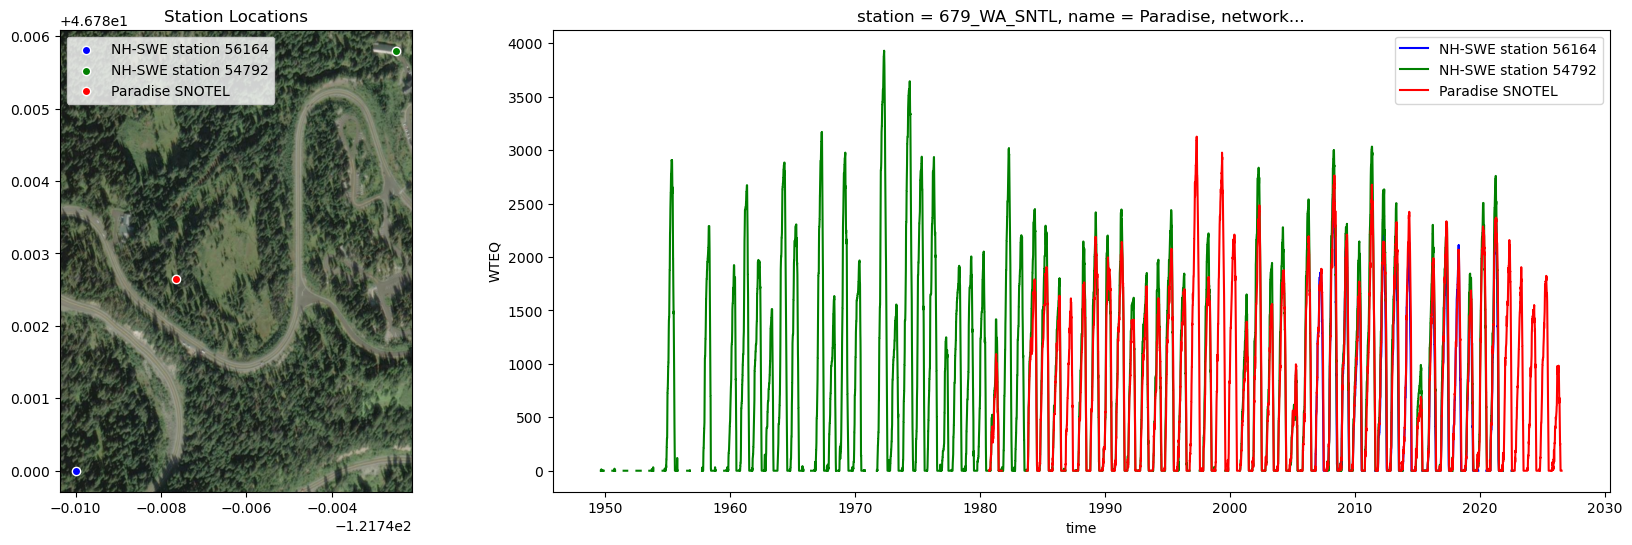

In [11]:
f,ax=plt.subplots(ncols=2, nrows=1, figsize=(20,6), gridspec_kw={'width_ratios': [1, 3]})

# geographic positions of stations 56164 and 54792, and the Paradise SNOTEL station
nh_station_56164_da = wa_ds.sel(station=56164)
nh_station_54792_da = wa_ds.sel(station=54792)
ax[0].scatter(nh_station_56164_da.longitude, nh_station_56164_da.latitude, label='NH-SWE station 56164', color='blue', edgecolor='white')
ax[0].scatter(nh_station_54792_da.longitude, nh_station_54792_da.latitude, label='NH-SWE station 54792', color='green', edgecolor='white')
ax[0].scatter(paradise_SNOTEL_swe_mm_da.longitude, paradise_SNOTEL_swe_mm_da.latitude, label='Paradise SNOTEL', color='red', edgecolor='white')
ax[0].legend()
ax[0].set_title('Station Locations')
ctx.add_basemap(ax[0], crs='EPSG:4326', source=ctx.providers.Esri.WorldImagery, attribution='')


# time series
wa_ds['swe'].sel(station=56164).plot(ax=ax[1], label='NH-SWE station 56164',color='blue')
wa_ds['swe'].sel(station=54792).plot(ax=ax[1], label='NH-SWE station 54792', color='green')
paradise_SNOTEL_swe_mm_da.plot(ax=ax[1], label='Paradise SNOTEL', color='red')

ax[1].legend()
f.savefig("figures/NH_SWE_vs_Paradise_SNOTEL_SWE.png", dpi=300, bbox_inches='tight')

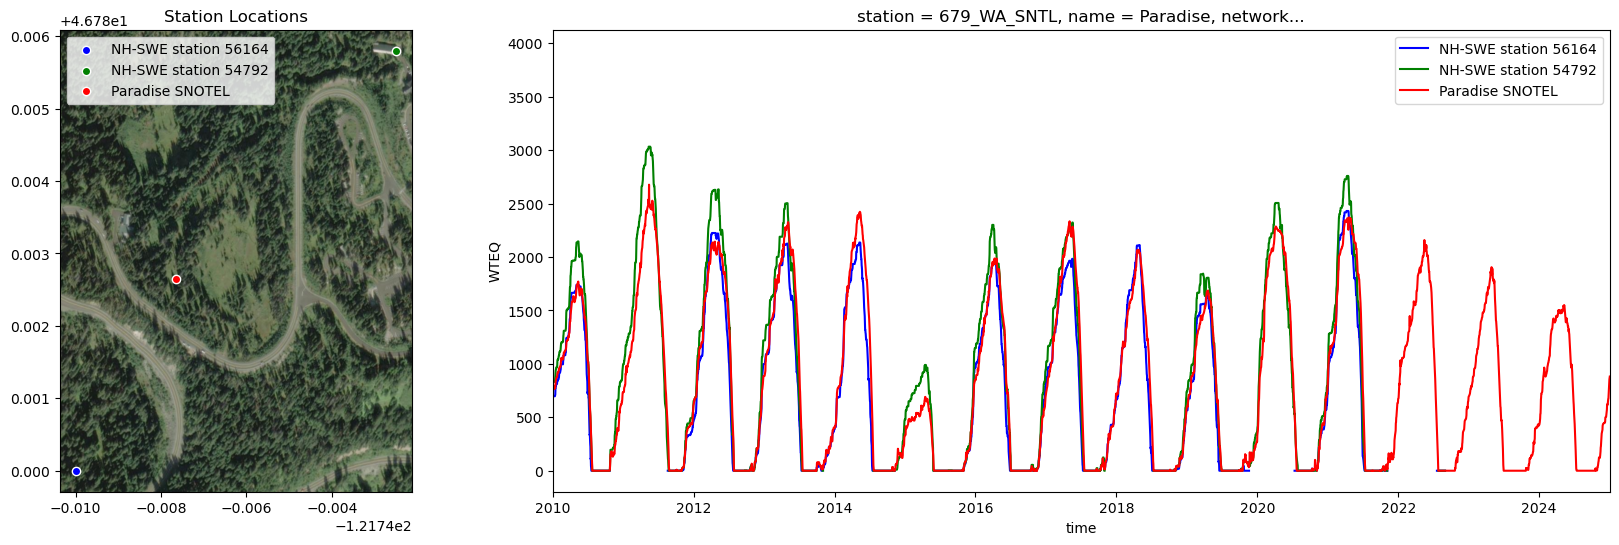

In [12]:
f,ax=plt.subplots(ncols=2, nrows=1, figsize=(20,6), gridspec_kw={'width_ratios': [1, 3]})

# geographic positions of stations 56164 and 54792, and the Paradise SNOTEL station
nh_station_56164_da = wa_ds.sel(station=56164)
nh_station_54792_da = wa_ds.sel(station=54792)
ax[0].scatter(nh_station_56164_da.longitude, nh_station_56164_da.latitude, label='NH-SWE station 56164', color='blue', edgecolor='white')
ax[0].scatter(nh_station_54792_da.longitude, nh_station_54792_da.latitude, label='NH-SWE station 54792', color='green', edgecolor='white')
ax[0].scatter(paradise_SNOTEL_swe_mm_da.longitude, paradise_SNOTEL_swe_mm_da.latitude, label='Paradise SNOTEL', color='red', edgecolor='white')
ax[0].legend()
ax[0].set_title('Station Locations')
ctx.add_basemap(ax[0], crs='EPSG:4326', source=ctx.providers.Esri.WorldImagery, attribution='')


# time series
wa_ds['swe'].sel(station=56164).plot(ax=ax[1], label='NH-SWE station 56164',color='blue')
wa_ds['swe'].sel(station=54792).plot(ax=ax[1], label='NH-SWE station 54792', color='green')
paradise_SNOTEL_swe_mm_da.plot(ax=ax[1], label='Paradise SNOTEL', color='red')

ax[1].legend()

ax[1].set_xlim([pd.to_datetime('2010-01-01'), pd.to_datetime('2024-12-31')])
f.savefig("figures/NH_SWE_vs_Paradise_SNOTEL_SWE_2010_2024.png", dpi=300, bbox_inches='tight')

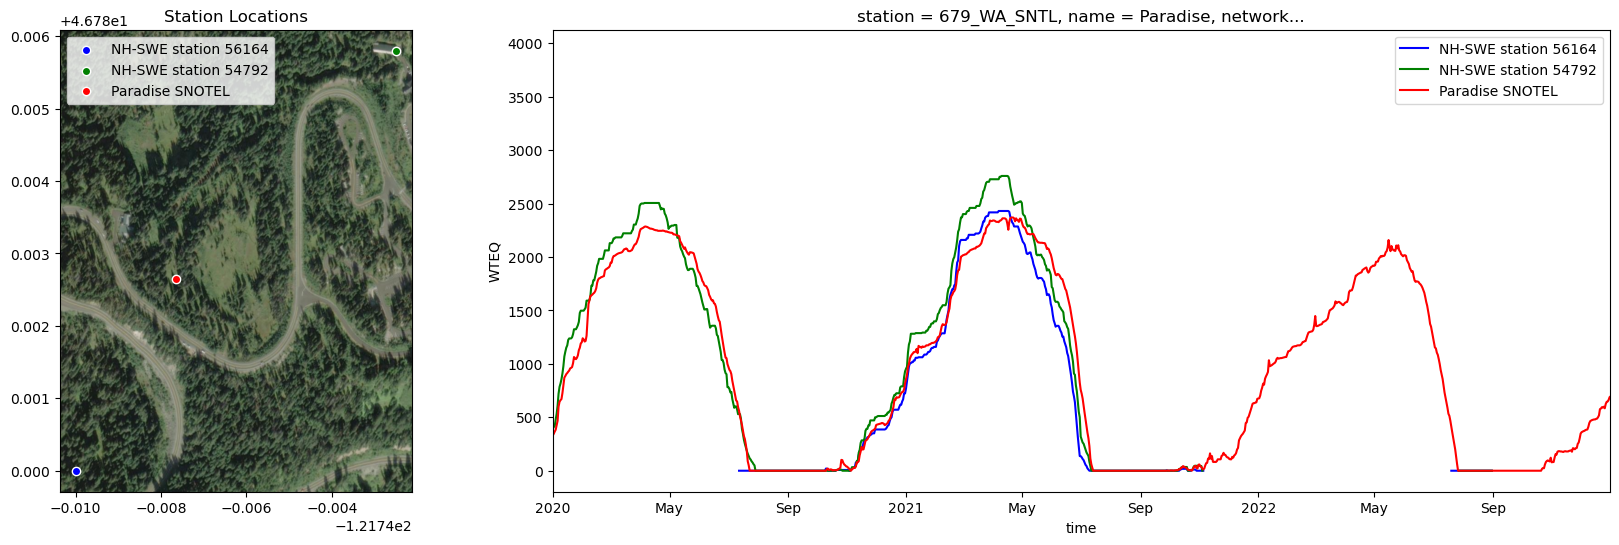

In [13]:
f,ax=plt.subplots(ncols=2, nrows=1, figsize=(20,6), gridspec_kw={'width_ratios': [1, 3]})

# geographic positions of stations 56164 and 54792, and the Paradise SNOTEL station
nh_station_56164_da = wa_ds.sel(station=56164)
nh_station_54792_da = wa_ds.sel(station=54792)
ax[0].scatter(nh_station_56164_da.longitude, nh_station_56164_da.latitude, label='NH-SWE station 56164', color='blue', edgecolor='white')
ax[0].scatter(nh_station_54792_da.longitude, nh_station_54792_da.latitude, label='NH-SWE station 54792', color='green', edgecolor='white')
ax[0].scatter(paradise_SNOTEL_swe_mm_da.longitude, paradise_SNOTEL_swe_mm_da.latitude, label='Paradise SNOTEL', color='red', edgecolor='white')
ax[0].legend()
ax[0].set_title('Station Locations')
ctx.add_basemap(ax[0], crs='EPSG:4326', source=ctx.providers.Esri.WorldImagery, attribution='')


# time series
wa_ds['swe'].sel(station=56164).plot(ax=ax[1], label='NH-SWE station 56164',color='blue')
wa_ds['swe'].sel(station=54792).plot(ax=ax[1], label='NH-SWE station 54792', color='green')
paradise_SNOTEL_swe_mm_da.plot(ax=ax[1], label='Paradise SNOTEL', color='red')

ax[1].legend()

ax[1].set_xlim([pd.to_datetime('2020-01-01'), pd.to_datetime('2022-12-31')])
f.savefig("figures/NH_SWE_vs_Paradise_SNOTEL_SWE_2020_2022.png", dpi=300, bbox_inches='tight')